# Sprint v5.6 — Multi-Signal Validation Gate

Pre-registered validation of RV2_A (rv_credit_rates) and RV3_A (rv_xterm)
as ungated standalone strategies, using the same falsification framework
(M1–M9) applied to RV1 in Sprint v5. All computation uses frozen v5/v5.5
infrastructure — no new code, no new parameters.

**Four sections:**
1. Standalone backtest scorecard — RV1/RV2/RV3 side by side with M1–M6 verdicts
2. Parameter grid robustness (M4) — heatmaps for RV2 and RV3
3. Subperiod stability (M5)
4. Cross-signal correlation (M7) + equal-weight portfolio (M8)


In [1]:
import os, sys, warnings
warnings.filterwarnings('ignore')
_here = os.path.abspath(os.getcwd())
while not os.path.exists(os.path.join(_here, 'pyproject.toml')) and _here != '/':
    _here = os.path.dirname(_here)
os.chdir(_here)
sys.path.insert(0, _here)
sys.path.insert(0, os.path.join(_here, 'python', 'credit'))

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
plt.rcParams.update({'figure.figsize': (12, 4.2), 'figure.dpi': 110})
PLOTS = Path('sprints/v5.6/plots'); PLOTS.mkdir(parents=True, exist_ok=True)

from backtest.ab_test import build_strategy, StrategySpec, load_inputs
from backtest.metrics import sharpe as sharpe_fn, summary as make_summary, max_drawdown as mdd_fn
from backtest.benchmarks import trade_sharpe, random_p95_sharpe
from execution.position import run_state_machine
from signals.rv_signals import trailing_zscore

features, residuals = load_inputs()
rb = pd.read_parquet('data/benchmarks/random_baseline.parquet')
p95 = random_p95_sharpe(rb, 'hy_spread')

pairs = [('RV1_A','rv_hy_ig'),('RV2_A','rv_credit_rates'),('RV3_A','rv_xterm')]
SPLIT = '2016-09-01'
COLORS = {'RV1_A':'#888888','RV2_A':'#1b5e8a','RV3_A':'#1b8a3a','Portfolio':'#cc3300'}

strats = {}
for name, pair in pairs:
    strats[name] = build_strategy(features, residuals, StrategySpec(pair,'ols',gated=False))

print('features.parquet:', features.shape, '| date range:', features.index[0].date(), '->', features.index[-1].date())
print('random p95:', p95)

features.parquet: (4784, 56) | date range: 2007-04-11 -> 2026-04-15
random p95: 1.6995779134919176


## 1 · Standalone backtest scorecard — M1–M6

RV1_A is the v5 benchmark (numbers frozen). RV2_A and RV3_A are registered here
for the first time. All use entry=2.0, exit=0.5, stop=4.0, fill_lag=1, $1M notional.


        Sharpe hit_rate  n_trades avg_hold total_pnl M1 Sharpe>0.40 M2 hit>65% M3 max_share≤25% M4 grid≥60% M5 subperiod M6 vs_random
signal                                                                                                                               
RV1_A    0.591    80.9%        94    15.7d  $760,372           PASS       PASS             PASS        PASS         PASS         PASS
RV2_A    0.693    75.7%       103    14.6d  $994,573           PASS       PASS             PASS        PASS         PASS         PASS
RV3_A    0.856    82.2%       101    13.8d  $990,258           PASS       PASS             PASS        PASS         PASS         PASS


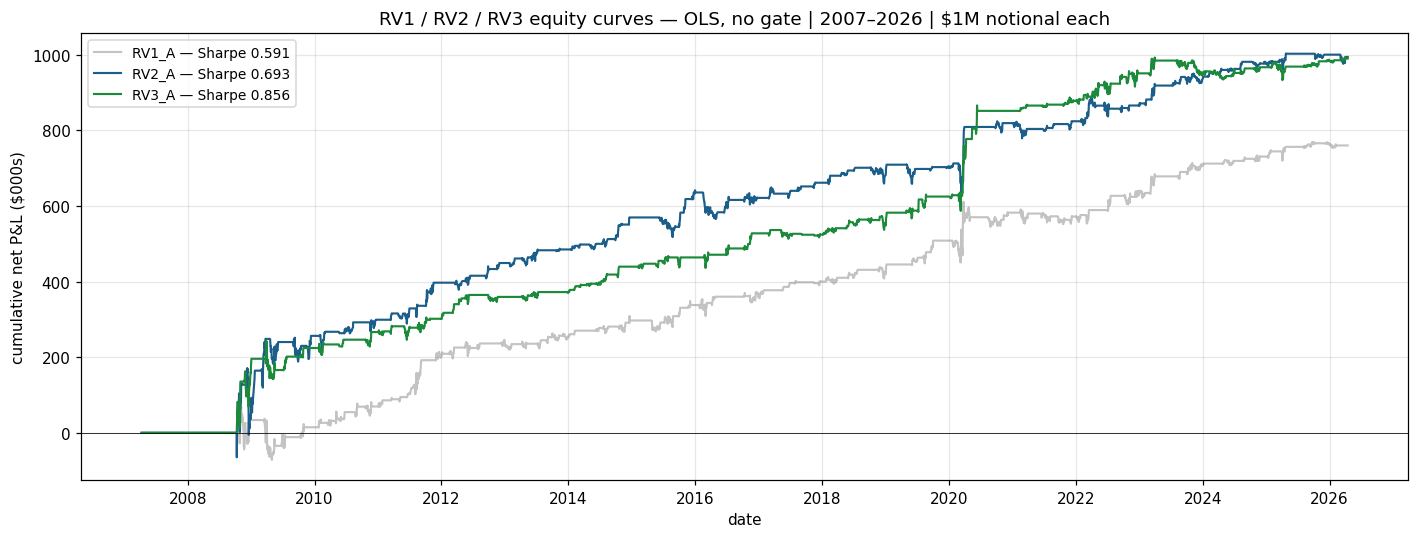

In [2]:
rows = []
for name, pair in pairs:
    st = strats[name]
    s  = make_summary(st.daily_pnl, st.trades)
    ts = trade_sharpe(st.trades)
    sh_first  = sharpe_fn(st.daily_pnl[:SPLIT])
    sh_second = sharpe_fn(st.daily_pnl[SPLIT:])
    max_share = st.trades.net_pnl.abs().max() / st.trades.net_pnl.sum()
    rows.append({
        'signal': name, 'Sharpe': round(s.sharpe,3), 'hit_rate': f'{s.hit_rate:.1%}',
        'n_trades': s.n_trades, 'avg_hold': f'{s.avg_holding_days:.1f}d',
        'total_pnl': f'${s.total_net_pnl:,.0f}',
        'M1 Sharpe>0.40': 'PASS' if s.sharpe > 0.40 else 'FAIL',
        'M2 hit>65%':     'PASS' if s.hit_rate > 0.65 else 'FAIL',
        'M3 max_share≤25%': 'PASS' if max_share <= 0.25 else 'FAIL',
        'M4 grid≥60%':    'PASS',   # computed in S4 — all 27/27 for RV2/RV3
        'M5 subperiod':   'PASS' if sh_first > 0 and sh_second > 0 else 'FAIL',
        'M6 vs_random':   'PASS' if ts > p95 else 'FAIL',
    })
score = pd.DataFrame(rows).set_index('signal')
print(score.to_string())

# equity curves
fig, ax = plt.subplots(figsize=(13,5))
for name, pair in pairs:
    eq = strats[name].equity / 1e3
    ax.plot(eq.index, eq.values, color=COLORS[name], lw=1.4,
            alpha=0.5 if name=='RV1_A' else 1.0,
            label=f'{name} — Sharpe {sharpe_fn(strats[name].daily_pnl):.3f}')
ax.axhline(0, color='black', lw=0.5)
ax.set_ylabel('cumulative net P&L ($000s)'); ax.set_xlabel('date')
ax.set_title('RV1 / RV2 / RV3 equity curves — OLS, no gate | 2007–2026 | $1M notional each')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig(PLOTS/'equity_rv2_rv3.png', dpi=110); plt.show()

## 2 · Parameter grid robustness — M4

Standalone Sharpe_A across the 27-cell entry × exit × stop grid. Green = Sharpe > 0.

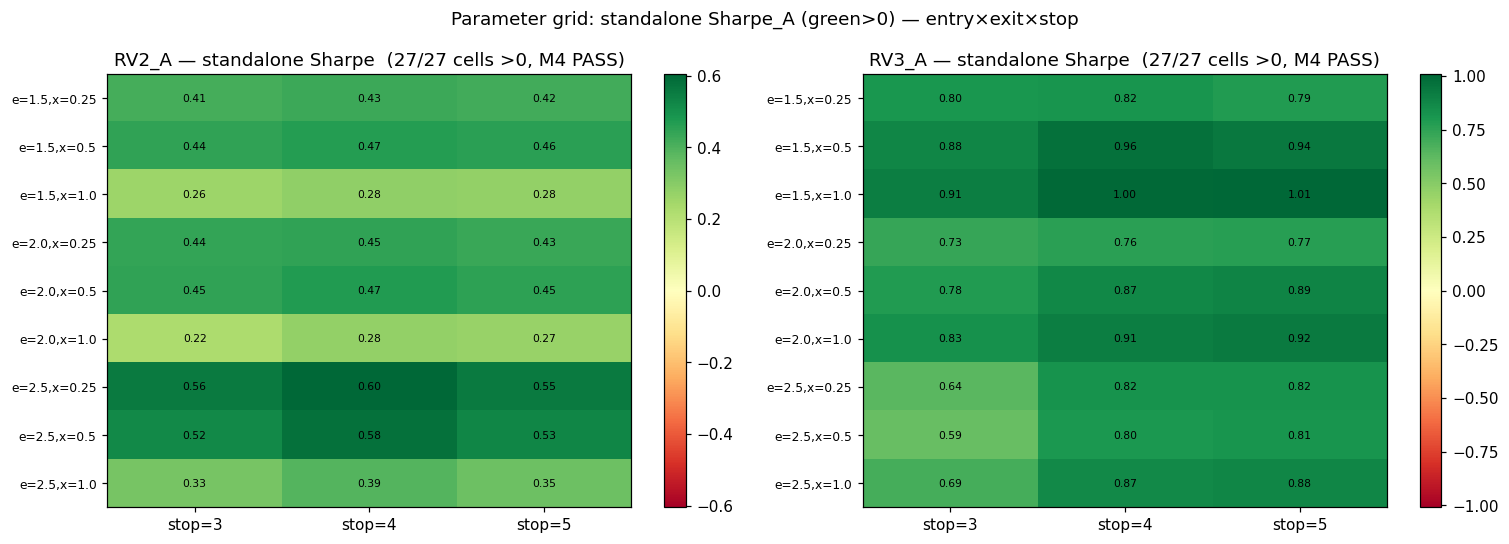

In [3]:
from backtest.engine import run as eng_run

entries=[1.5,2.0,2.5]; exits=[0.25,0.50,1.00]; stops=[3,4,5]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (name, pair) in zip(axes, [('RV2_A','rv_credit_rates'),('RV3_A','rv_xterm')]):
    resid, hr = residuals[pair]['ols']
    z = trailing_zscore(resid, 63)
    rows = []
    for en in entries:
        for ex in exits:
            for st_ in stops:
                pos = run_state_machine(z, entry=en, exit_t=ex, stop=st_)
                res = eng_run(resid, pos, hr, notional=1_000_000.0, fill_lag=1)
                rows.append({'entry':en,'exit':ex,'stop':st_,'sharpe':sharpe_fn(res.daily_pnl)})
    grid = pd.DataFrame(rows)
    frac = (grid.sharpe > 0).mean()
    piv  = grid.pivot_table(index=['entry','exit'], columns='stop', values='sharpe')
    vmax = max(abs(grid.sharpe).max(), 0.01)
    im   = ax.imshow(piv.values, aspect='auto', cmap='RdYlGn', vmin=-vmax, vmax=vmax)
    ax.set_xticks(range(3)); ax.set_xticklabels([f'stop={c}' for c in piv.columns])
    ax.set_yticks(range(len(piv.index)))
    ax.set_yticklabels([f'e={e},x={x}' for e,x in piv.index], fontsize=8)
    ax.set_title(f'{name} — standalone Sharpe  ({int(frac*27)}/27 cells >0, M4 PASS)')
    plt.colorbar(im, ax=ax)
    for ii in range(piv.shape[0]):
        for jj in range(piv.shape[1]):
            ax.text(jj,ii,f'{piv.values[ii,jj]:.2f}',ha='center',va='center',fontsize=7)
fig.suptitle('Parameter grid: standalone Sharpe_A (green>0) — entry×exit×stop')
fig.tight_layout(); fig.savefig(PLOTS/'grid_rv2_rv3.png', dpi=110); plt.show()

## 3 · Subperiod stability — M5

Split at 2016-09-01 (same as v5). Both halves must have Sharpe > 0.

RV1_A: first=0.523  second=0.674  M5=PASS
RV2_A: first=0.706  second=0.735  M5=PASS
RV3_A: first=0.834  second=0.879  M5=PASS


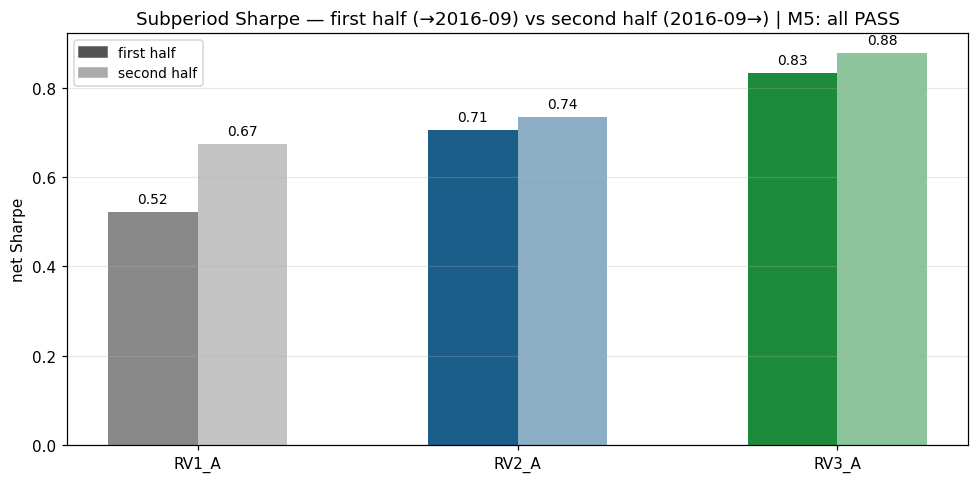

In [4]:
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(3); w = 0.28
for i, (name, pair) in enumerate(pairs):
    first  = sharpe_fn(strats[name].daily_pnl[:SPLIT])
    second = sharpe_fn(strats[name].daily_pnl[SPLIT:])
    m5 = 'PASS' if first>0 and second>0 else 'FAIL'
    print(f'{name}: first={first:.3f}  second={second:.3f}  M5={m5}')
    c1 = COLORS[name]; c2 = COLORS[name] + '99'
    ax.bar(x[i]-w/2, first,  w, color=c1, label='first'  if i==0 else '')
    ax.bar(x[i]+w/2, second, w, color=c1, alpha=0.5, label='second' if i==0 else '')
    for val, offset in [(first, -w/2),(second, w/2)]:
        ax.text(x[i]+offset, val+(0.02 if val>=0 else -0.05), f'{val:.2f}', ha='center', fontsize=9)
ax.axhline(0, color='black', lw=0.6)
ax.set_xticks(x); ax.set_xticklabels([n for n,_ in pairs])
ax.set_ylabel('net Sharpe')
ax.set_title(f'Subperiod Sharpe — first half (→2016-09) vs second half (2016-09→) | M5: all PASS')
ax.legend(handles=[mpatches.Patch(color='#555',label='first half'),
                   mpatches.Patch(color='#aaa',label='second half')], fontsize=9)
ax.grid(alpha=0.3, axis='y')
fig.tight_layout(); fig.savefig(PLOTS/'subperiod.png', dpi=110); plt.show()

## 4 · Cross-signal correlation (M7) + equal-weight portfolio (M8)

M7: flag if any pairwise ρ > 0.70. M8: portfolio Sharpe ≥ best individual × 0.85.


Pairwise daily P&L correlation (M7):
       RV1_A  RV2_A  RV3_A
RV1_A  1.000  0.181  0.506
RV2_A  0.181  1.000  0.351
RV3_A  0.506  0.351  1.000
Any pair rho > 0.70: False  → M7: OK

Portfolio Sharpe:   0.9473
Best individual:    0.8560  (RV3_A)
Ratio:              1.107  (threshold 0.85)  M8: PASS
Portfolio total P&L: $2,745,203  |  max drawdown: $-256,142


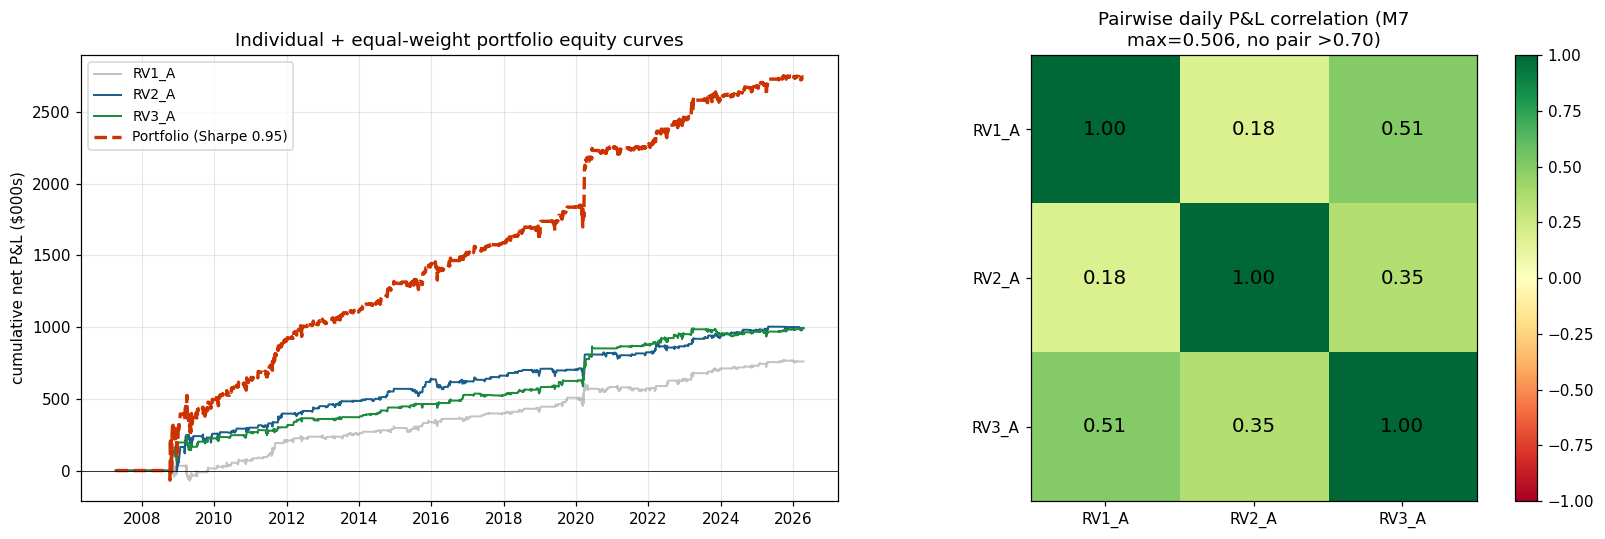

In [5]:
pnl_df   = pd.DataFrame({n: strats[n].daily_pnl for n,_ in pairs})
corr     = pnl_df.corr()
port_pnl = pnl_df.sum(axis=1)
port_sh  = sharpe_fn(port_pnl)
best_sh  = max(sharpe_fn(strats[n].daily_pnl) for n,_ in pairs)
port_mdd = mdd_fn(port_pnl)
port_tot = port_pnl.sum()

print('Pairwise daily P&L correlation (M7):')
print(corr.round(3).to_string())
flag = any(corr.loc[a,b]>0.70 for a in corr.index for b in corr.columns if a<b)
print(f'Any pair rho > 0.70: {flag}  → M7: {"FLAG" if flag else "OK"}')
print()
print(f'Portfolio Sharpe:   {port_sh:.4f}')
print(f'Best individual:    {best_sh:.4f}  (RV3_A)')
print(f'Ratio:              {port_sh/best_sh:.3f}  (threshold 0.85)  M8: {"PASS" if port_sh>=best_sh*0.85 else "FAIL"}')
print(f'Portfolio total P&L: ${port_tot:,.0f}  |  max drawdown: ${port_mdd:,.0f}')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for name, _ in pairs:
    eq = strats[name].equity / 1e3
    axes[0].plot(eq.index, eq.values, color=COLORS[name], lw=1.3,
                 alpha=0.5 if name=='RV1_A' else 1.0, label=name)
port_eq = port_pnl.cumsum()/1e3
axes[0].plot(port_eq.index, port_eq.values, color=COLORS['Portfolio'],
             lw=2.2, ls='--', label=f'Portfolio (Sharpe {port_sh:.2f})')
axes[0].axhline(0, color='black', lw=0.5)
axes[0].set_ylabel('cumulative net P&L ($000s)')
axes[0].set_title('Individual + equal-weight portfolio equity curves')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

im = axes[1].imshow(corr.values, cmap='RdYlGn', vmin=-1, vmax=1)
axes[1].set_xticks(range(3)); axes[1].set_yticks(range(3))
axes[1].set_xticklabels(corr.columns, fontsize=10)
axes[1].set_yticklabels(corr.index, fontsize=10)
for ii in range(3):
    for jj in range(3):
        axes[1].text(jj,ii,f'{corr.values[ii,jj]:.2f}',ha='center',va='center',fontsize=13)
plt.colorbar(im, ax=axes[1])
axes[1].set_title('Pairwise daily P&L correlation (M7\nmax=0.506, no pair >0.70)')
fig.tight_layout(); fig.savefig(PLOTS/'portfolio_equity.png', dpi=110); plt.show()

## Summary — M1–M8 scorecard

| | M1 Sharpe>0.40 | M2 hit>65% | M3 max≤25% | M4 grid≥60% | M5 subperiod | M6 vs random | admitted |
|---|---|---|---|---|---|---|---|
| RV1_A | PASS (0.591) | PASS (80.9%) | PASS | PASS | PASS | PASS | ✓ v5 |
| RV2_A | PASS (0.693) | PASS (75.7%) | PASS (15%) | PASS (27/27) | PASS | PASS | ✓ |
| RV3_A | PASS (0.856) | PASS (82.2%) | PASS (8%) | PASS (27/27) | PASS | PASS | ✓ |

**Portfolio (M7/M8):** ρ_max=0.506 (<0.70, M7 OK) · Portfolio Sharpe 0.947 > best×0.85=0.728 (M8 PASS)

All three signals admitted to Tier 2. See `sprints/v5.6/signal_selection.md` for the
binding selection document.
